# Customer Churn Analysis

**Business question:** Which customers are leaving, and what factors are linked to churn?

## Overview
This project analyzes subscription churn for a 200-customer sample dataset. Data is pulled from a SQLite database with three tables (customer, subscription and support), cleaned and merged with Pandas, then explored through KPIs and visualizations to find where churn is highest.

## Tools
Python | Pandas | NumPy | Matplotlib | Seaborn | SQLite | Jupyter Notebook

## Workflow
1. **Import data:** load the customer, subscription and support tables from SQLite
2. **Clean data:** rename columns, fix data types, standardize gender values, fill missing countries
3. **Feature engineering:** churn flag, complaint count, tenure, churn-risk segments (low / medium / high)
4. **Analysis:** churn rate, retention rate, churn by plan / state / acquisition channel, ARPU, tenure, revenue lost, escalation rate
5. **Visualization:** monthly churn trend, churn by plan and state, correlation heatmap, catplot
6. **Findings and recommendations:** see the last section

**Author:** Manish Saini

# Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

# Import Database

In [3]:
conn = sqlite3.connect("customer_churn.db")
sql = """
        SELECT "name" FROM sqlite_master
        WHERE TYPE = "table";
        """
tables = pd.read_sql(sql, conn)

for t in tables["name"]:
    df = pd.read_sql(f"SELECT * FROM {t};", conn)
    globals()[f"df_{t}"] = df
    print(f"Created Dataframe : df_{t}")

conn.close()

Created Dataframe : df_db_customer
Created Dataframe : df_db_subscription
Created Dataframe : df_db_support


# Data Cleaning

In [4]:
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [5]:
# a. Rename column
df_db_customer.rename({"name" : "customer_name"}, axis = 1, inplace = True)

In [6]:
# b. Drop columns
df_db_customer.drop(["interests", "pincode"], axis = 1, inplace = True)

In [7]:
# d. Data Standardization
df_db_customer["gender"] = df_db_customer["gender"].replace({"Women" : "Female", "Men" : "Male"})

In [8]:
df_db_customer[df_db_customer["country"].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,NaN,Delhi,Female,1988-12-10 00:00:00
8,0015-UOCOJ,maya,NaN,Kathmandu,Female,1985-07-07 00:00:00
12,0018-NYROU,chitra,NaN,Telangana,Female,2004-12-01 00:00:00


In [9]:
state_country_mapping = df_db_customer.dropna(subset = "country").set_index("state")["country"].to_dict()
df_db_customer["country"] = df_db_customer["country"].fillna(df_db_customer["state"].map(state_country_mapping))

In [11]:
# c. Change datatype
df_db_customer["dob"] = pd.to_datetime(df_db_customer["dob"])

In [12]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customerid     200 non-null    str           
 1   customer_name  200 non-null    str           
 2   country        200 non-null    str           
 3   state          200 non-null    str           
 4   gender         200 non-null    str           
 5   dob            200 non-null    datetime64[us]
dtypes: datetime64[us](1), str(5)
memory usage: 9.5 KB


In [13]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [15]:
# change datatype - fix date columns
df_db_subscription[["subscription_start_date", "renewal_date", "cancellation_date"]] = df_db_subscription.iloc[:, [1, 3, 6]].apply(pd.to_datetime, format = "%d-%m-%Y")

In [16]:
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               200 non-null    str           
 1   subscription_start_date  200 non-null    datetime64[us]
 2   subscription_type        200 non-null    str           
 3   renewal_date             200 non-null    datetime64[us]
 4   plan_type                200 non-null    str           
 5   contract_type            200 non-null    str           
 6   cancellation_date        54 non-null     datetime64[us]
 7   cancellation_reason      54 non-null     str           
 8   monthly_charges          200 non-null    float64       
 9   cltv                     200 non-null    int64         
 10  churn_score              200 non-null    int64         
 11  churn_flag               200 non-null    int64         
dtypes: datetime64[us](3), float64(1), int64(3), str

In [17]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,NaN
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,NaN


In [18]:
# drop columns
df_db_support.drop(df_db_support.columns[-2:], axis = 1, inplace = True)

In [20]:
# Change Datatype
df_db_support["complaint_date"] = pd.to_datetime(df_db_support["complaint_date"])

In [22]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   customerid       71 non-null     str           
 1   complaint_date   71 non-null     datetime64[us]
 2   escalations      71 non-null     str           
 3   csat_score       71 non-null     int64         
 4   complaint_count  71 non-null     int64         
dtypes: datetime64[us](1), int64(2), str(2)
memory usage: 2.9 KB


# Feature Engineering

In [23]:
df_db_subscription["churn_flag"] = np.where(df_db_subscription["cancellation_date"].notna(), 1, 0)

In [24]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Referral,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Referral,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [25]:
df_db_support["complaint_count"] = df_db_support.groupby("customerid")["customerid"].transform("count")

In [26]:
df_db_support = df_db_support.sort_values("complaint_date").drop_duplicates("customerid", keep = "last")

In [27]:
df = df_db_subscription.merge(df_db_customer, "left", "customerid").merge(df_db_support, "left", "customerid")

In [28]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count
0,0002-ORFBO,2021-03-15,Referral,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,1.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,...,0,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN,NaN
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,...,0,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN,NaN
4,0013-EXCHZ,2023-01-05,Referral,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,1,mira,India,Delhi,Female,1990-05-05,2024-01-20,Y,20.0,1.0


# Data Analysis

In [29]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='str')

In [30]:
churn_rate = df["churn_flag"].mean() * 100
print(f"Churn Rate = {round(churn_rate, 2)}%")

Churn Rate = 27.0%


In [31]:
retention_rate = 100 - churn_rate
print(f"Retention Rate = {round(retention_rate, 2)}%")

Retention Rate = 73.0%


In [32]:
churn_by_plan = df.groupby("plan_type")["churn_flag"].mean().mul(100).round(2).reset_index(name = "churn_rate_pct")
print(churn_by_plan)

  plan_type  churn_rate_pct
0     Basic           39.34
1   Premium           13.56
2  Standard           27.50


In [33]:
churn_by_state = df.groupby("state")["churn_flag"].mean().mul(100).round(2).reset_index(name = "churn_rate_pct")
print(churn_by_state)

           state  churn_rate_pct
0          Delhi           32.35
1      Karnataka           21.05
2      Kathmandu           25.00
3    Maharashtra           32.00
4      Meghalaya           23.81
5       Nagaland           25.00
6      Rajasthan           36.00
7      Telangana           23.53
8  Uttar Pradesh           18.52


In [34]:
churn_by_subscription = df.groupby("subscription_type")["churn_flag"].mean().mul(100).round(2).reset_index(name = "churn_rate_pct")
print(churn_by_subscription)

  subscription_type  churn_rate_pct
0           Organic           11.54
1              Paid           22.95
2          Referral           50.82


In [35]:
arpu = df["monthly_charges"].mean().round(2)
print(f"ARPU = {arpu}")

ARPU = 15.16


In [36]:
df["tenure_days"] = np.where(df["cancellation_date"].notna(), 
        (df["cancellation_date"] - df["subscription_start_date"]).dt.days,
        (pd.Timestamp.today() - df["subscription_start_date"]).dt.days)

average_tenure = df["tenure_days"].mean().round()
print(f"average_tenure = {average_tenure} days")

average_tenure = 1700.0 days


In [37]:
revenue_at_risk = df.loc[df["churn_flag"] == 1, "monthly_charges"].sum()
print(f"Revenue at risk = {revenue_at_risk}")

Revenue at risk = 682.46


In [38]:
escalation_rate = (df["escalations"] == "Y").mean() * 100
print(f"Escalation rate = {round(escalation_rate, 2)}%")

Escalation rate = 19.5%


In [39]:
average_complaints = df["complaint_count"].sum() / df["customerid"].nunique()
print(f"average complaints per user = {round(average_complaints, 2)}")

average complaints per user = 0.36


In [40]:
df["escalations"] = np.where(df["escalations"] == "Y", 1, 0)

In [41]:
correlation = df["escalations"].corr(df["churn_flag"])
print(f"Correlation between escalation & churn = {round(correlation, 2)}")

Correlation between escalation & churn = 0.64


In [42]:
conditions = [
                df["churn_score"] < 50,
                df["churn_score"] < 70,
                df["churn_score"] >= 70
            ]
choices = ["low", "medium", "high"]

df["churn_risk"] = np.select(conditions, choices, "unknown")

In [43]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,tenure_days,churn_risk
0,0002-ORFBO,2021-03-15,Referral,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,India,Maharashtra,Male,1982-04-12,NaT,0,NaN,NaN,2017.0,low
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,India,Karnataka,Male,1995-11-23,2024-08-28,1,10.0,1.0,1501.0,high
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,...,India,Delhi,Female,1978-02-15,NaT,0,NaN,NaN,1402.0,low
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,...,India,Nagaland,Male,2001-08-30,NaT,0,NaN,NaN,2692.0,low
4,0013-EXCHZ,2023-01-05,Referral,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,India,Delhi,Female,1990-05-05,2024-01-20,1,20.0,1.0,419.0,high


# Visualization using Matplotlib

In [44]:
df_visual = df.copy()

In [45]:
df_visual["cancellation_month"] = df_visual["cancellation_date"].dt.to_period("M")

In [46]:
churn_trend = df_visual[df_visual["churn_flag"] == 1].groupby("cancellation_month")["cancellation_month"].size()

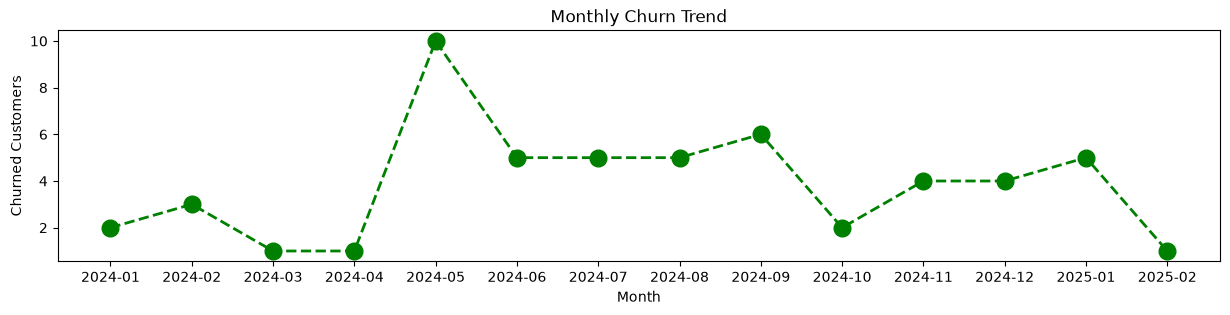

In [47]:
plt.figure(figsize = (15, 3))
plt.plot(churn_trend.index.astype("str"), churn_trend.values, color='green', marker='o', linestyle='dashed', linewidth=2, markersize=12)
plt.title("Monthly Churn Trend")
plt.xlabel("Month")
plt.ylabel("Churned Customers")
plt.show()

In [48]:
df_visual.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,tenure_days,churn_risk,cancellation_month
0,0002-ORFBO,2021-03-15,Referral,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,Maharashtra,Male,1982-04-12,NaT,0,NaN,NaN,2017.0,low,NaT
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,Karnataka,Male,1995-11-23,2024-08-28,1,10.0,1.0,1501.0,high,2024-09
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,...,Delhi,Female,1978-02-15,NaT,0,NaN,NaN,1402.0,low,NaT
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,...,Nagaland,Male,2001-08-30,NaT,0,NaN,NaN,2692.0,low,NaT
4,0013-EXCHZ,2023-01-05,Referral,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,Delhi,Female,1990-05-05,2024-01-20,1,20.0,1.0,419.0,high,2024-02


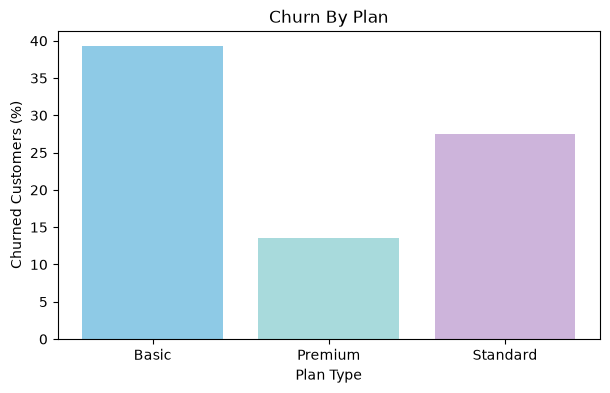

In [49]:
churn_plan = df_visual.groupby("plan_type")["churn_flag"].mean().mul(100).round(2)
plt.figure(figsize = (7, 4))
plt.bar(churn_plan.index, churn_plan.values, color = ["#8ECae6", "#A8DADC", "#CDB4DB"])
plt.title("Churn By Plan")
plt.xlabel("Plan Type")
plt.ylabel("Churned Customers (%)")
plt.show()

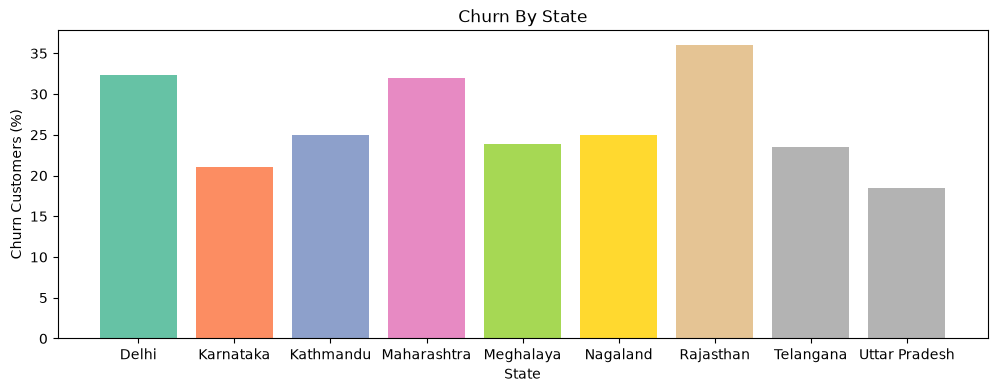

In [50]:
churn_state = df_visual.groupby("state")["churn_flag"].mean().mul(100).round(2)
colors = plt.cm.Set2(np.linspace(0, 1, len(churn_state)))

plt.figure(figsize = (12, 4))
plt.bar(churn_state.index, churn_state.values, color = colors)
plt.title("Churn By State")
plt.xlabel("State")
plt.ylabel("Churn Customers (%)")
plt.show()

In [51]:
df_encoded = df_visual[["plan_type", "contract_type", "churn_risk", "churn_score", "churn_flag", "escalations"]]

order_mapping = {
                "plan_type" : ["Basic", "Standard", "Premium"],
                "contract_type" : ["Monthly", "Annual"],
                "churn_risk" : ["low", "medium", "high"]
                }
for col, order in order_mapping.items():
    df_encoded[col] = pd.Categorical(df_encoded[col].astype("category"), categories = order, ordered = True).codes

<Axes: >

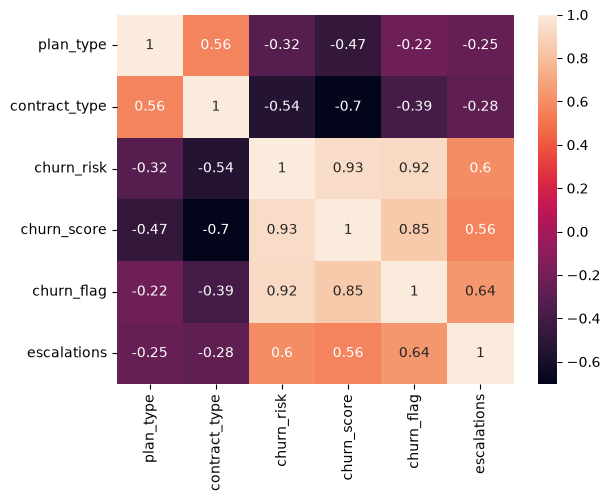

In [52]:
sns.heatmap(df_encoded.corr(), annot = True)

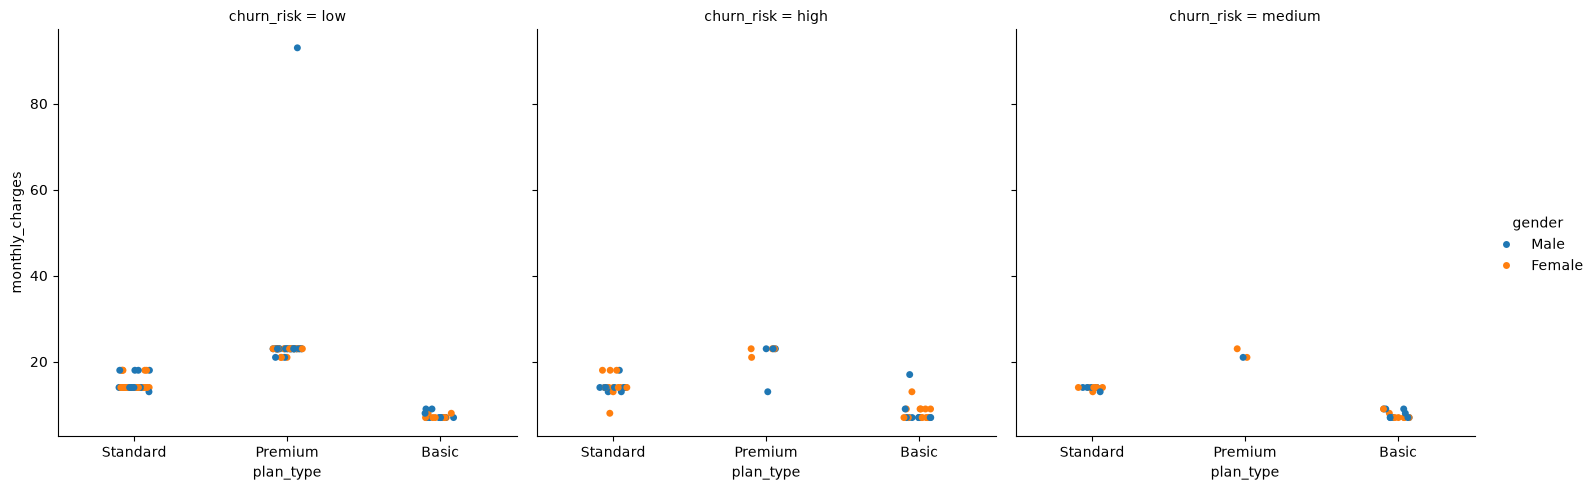

In [53]:
sns.catplot(df_visual, x = "plan_type", y = "monthly_charges", hue = "gender", col = "churn_risk")

# Pivot Table

In [54]:
pd.pivot_table(df_visual, ["customerid", "monthly_charges", "churn_flag"], "plan_type", aggfunc = {"customerid" : "nunique", "monthly_charges" : "sum", "churn_flag" : "mean"}, sort = False)

,customerid,monthly_charges,churn_flag
plan_type,,,
Standard,80,1159.20,0.275000
Premium,59,1400.41,0.135593
Basic,61,471.39,0.393443


# Key Findings and Recommendations

## Key Metrics
| Metric | Value |
|---|---|
| Churn rate | 27% (54 of 200 customers) |
| Retention rate | 73% |
| ARPU (average monthly charge) | 15.16 |
| Average customer tenure | 1,700 days |
| Monthly revenue from churned customers | 682.46 (about 22.5% of total monthly charges) |
| Escalation rate | 19.5% |
| Average complaints per customer | 0.36 |

## Key Findings
1. **Basic plan customers churn the most.** Churn is 39.3% on Basic vs 27.5% on Standard and 13.6% on Premium.
2. **Referral-acquired customers are the biggest risk.** Referral churn is 50.8%, compared with 22.9% for Paid and 11.5% for Organic.
3. **Escalated complaints are strongly linked to churn.** The correlation between escalation and churn is 0.64.
4. **Churn varies by state.** Rajasthan (36%), Delhi (32.4%) and Maharashtra (32%) are highest, while Uttar Pradesh (18.5%) is lowest.
5. **Churned customers account for about a fifth of monthly revenue,** so reducing churn has a direct revenue impact.

## Recommendations
1. **Review the referral channel.** Check who is being referred and how they are onboarded, since half of them leave.
2. **Resolve escalations quickly.** Set up a fast-track process for escalated complaints and follow up after resolution.
3. **Give Basic customers a reason to stay.** Test upgrade offers or annual-plan incentives, since Basic has the weakest retention.
4. **Focus retention efforts on high-churn states** (Rajasthan, Delhi, Maharashtra) and investigate local causes.
5. **Use the churn-risk segments** (low / medium / high) to trigger outreach to high-risk customers before they cancel.